# CBA 2026 SHAP Analysis: Target-Level Attribution and Performance

Selected +CNV MOSA run: `20260505_131645`.

This notebook connects target-level SHAP summaries to downstream selected TabPFN performance. It uses the selected standard TabPFN `feature_augmentation` setting (`expanded/mosa_all`) and compares target-level Pearson r against the random-forest `overlap/original` baseline recorded in the model-comparison outputs.

Figures and derived tables are saved to `reports/cba2026/shap_analysis/20260505_131645/`.


In [14]:
from pathlib import Path
import textwrap
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

TIMESTAMP = "20260505_131645"
TARGET_META = {
    "crisprcas9": "CRISPR-Cas12",
    "drugresponse": "Drug response",
}
OMIC_ORDER = [
    "transcriptomics",
    "methylation",
    "drugresponse",
    "crisprcas9",
    "conditionals",
    "copynumber",
]
OMIC_COLORS = {
    "transcriptomics": "#0072B2",
    "methylation": "#009E73",
    "drugresponse": "#D55E00",
    "crisprcas9": "#CC79A7",
    "conditionals": "#666666",
    "copynumber": "#E69F00",
}
TARGET_COLORS = {
    "CRISPR-Cas12": "#0072B2",
    "Drug response": "#D55E00",
}


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "reports" / "vae" / "files").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing reports/vae/files and docs.")


ROOT = find_repo_root()
FILES_DIR = ROOT / "reports" / "vae" / "files"
COMPARE_DIR = ROOT / "reports" / "model_comparison_cnv_mosa_only" / "feature_augmentation" / TIMESTAMP
FIG_DIR = ROOT / "reports" / "cba2026" / "shap_analysis" / TIMESTAMP
FIG_DIR.mkdir(parents=True, exist_ok=True)


def set_nature_style():
    sns.set_theme(style="white", context="paper")
    mpl.rcParams.update({
        "figure.dpi": 180,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
        "font.family": "DejaVu Sans",
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2.5,
        "ytick.major.size": 2.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })


set_nature_style()


def shap_paths(target_family):
    return {
        "values": FILES_DIR / f"{TIMESTAMP}_shap_values_{target_family}_mean_abs.csv.gz",
        "feature_rank": FILES_DIR / f"{TIMESTAMP}_shap_feature_ranking_{target_family}_mean_abs.csv",
        "omic_rank": FILES_DIR / f"{TIMESTAMP}_shap_omic_ranking_{target_family}_mean_abs.csv",
        "top_features": FILES_DIR / f"{TIMESTAMP}_shap_values_top_features_{target_family}_mean_abs.feather",
    }


def require_files(paths):
    missing = [p for p in paths if not p.exists()]
    if missing:
        rel = "\n".join(str(p.relative_to(ROOT)) for p in missing)
        raise FileNotFoundError(f"Missing required input files:\n{rel}")


def clean_feature_name(feature, width=46):
    feature = str(feature)
    if "_" in feature:
        _, feature = feature.split("_", 1)
    feature = feature.replace("__", " / ").replace("_", " ")
    return textwrap.shorten(feature, width=width, placeholder="...")


def save_figure(fig, stem):
    paths = []
    for ext in ("png", "pdf", "svg"):
        path = FIG_DIR / f"{stem}.{ext}"
        fig.savefig(path)
        paths.append(path)
    return paths

print(f"ROOT: {ROOT}")
print(f"FIG_DIR: {FIG_DIR}")


ROOT: /mnt/scratch/scai/PhenPredCCMA
FIG_DIR: /mnt/scratch/scai/PhenPredCCMA/reports/cba2026/shap_analysis/20260505_131645


## Load SHAP Top-Feature Tables and Per-Target Metrics


In [15]:
required = []
for target_family in TARGET_META:
    required.append(shap_paths(target_family)["top_features"])
required.extend([
    COMPARE_DIR / "combined_per_target.csv",
    COMPARE_DIR / "summary_model_comparison.csv",
])
require_files(required)

top_features = {
    target_family: pd.read_feather(shap_paths(target_family)["top_features"]).assign(
        target_family=target_family,
        target_label=target_label,
    )
    for target_family, target_label in TARGET_META.items()
}
top_all = pd.concat(top_features.values(), ignore_index=True)
per_target = pd.read_csv(COMPARE_DIR / "combined_per_target.csv")
summary_model = pd.read_csv(COMPARE_DIR / "summary_model_comparison.csv")

display(summary_model.query("sample_frame == 'expanded' and variant == 'mosa_all'")[[
    "target_family",
    "test_pearsonr_tabpfn",
    "test_pearsonr_random_forest",
    "delta_test_pearsonr_tabpfn_minus_random_forest",
]])
print(top_all.shape)
print(per_target.shape)


,target_family,test_pearsonr_tabpfn,test_pearsonr_random_forest,delta_test_pearsonr_tabpfn_minus_random_forest
0,crisprcas9,0.212351,0.181942,0.030409
6,drugresponse,0.319440,0.262647,0.056793


(200000, 6)
(12000, 11)


## Build Target-Level SHAP Profiles

The runner exported the top 200 features per target. The composition metrics below are based on those top-200 rows for each target.


In [16]:
def summarize_top200(df):
    df = df.sort_values(["target_name", "mean_abs_shap"], ascending=[True, False]).copy()
    target_family = df["target_family"].iloc[0]
    target_label = df["target_label"].iloc[0]

    total = df.groupby("target_name")["mean_abs_shap"].sum().rename("top200_total_shap")
    top1 = (df.groupby("target_name").head(1).groupby("target_name")["mean_abs_shap"].sum() / total).rename("top1_share")
    top10 = (df.groupby("target_name").head(10).groupby("target_name")["mean_abs_shap"].sum() / total).rename("top10_share")

    omic = df.groupby(["target_name", "omic_layer"], as_index=False)["mean_abs_shap"].sum()
    omic["share_top200"] = omic["mean_abs_shap"] / omic["target_name"].map(total)
    share = omic.pivot_table(index="target_name", columns="omic_layer", values="share_top200", fill_value=0)
    eps = 1e-12
    n_omics = max(share.shape[1], 1)
    entropy = (-(share * np.log(share + eps)).sum(axis=1) / np.log(n_omics)).rename("omic_entropy_top200")
    dominant_omic = share.idxmax(axis=1).rename("dominant_omic_top200")
    dominant_share = share.max(axis=1).rename("dominant_omic_share_top200")

    cnv_count = df[df["omic_layer"] == "copynumber"].groupby("target_name").size().rename("copynumber_feature_count_top200")
    profile = pd.concat([total, top1, top10, entropy, dominant_omic, dominant_share, cnv_count], axis=1).fillna({"copynumber_feature_count_top200": 0})

    share = share.add_prefix("share_").reset_index()
    profile = profile.reset_index().merge(share, on="target_name", how="left")
    for layer in OMIC_ORDER:
        col = f"share_{layer}"
        if col not in profile:
            profile[col] = 0.0
    profile["target_family"] = target_family
    profile["target_label"] = target_label
    profile["copynumber_feature_count_top200"] = profile["copynumber_feature_count_top200"].astype(int)
    return profile

shap_profile = pd.concat([summarize_top200(df) for df in top_features.values()], ignore_index=True)
display(shap_profile.head())
display(shap_profile.groupby("target_label")[["top200_total_shap", "top1_share", "top10_share", "omic_entropy_top200", "share_copynumber"]].describe().round(4))


,target_name,top200_total_shap,top1_share,top10_share,omic_entropy_top200,dominant_omic_top200,dominant_omic_share_top200,copynumber_feature_count_top200,share_conditionals,share_copynumber,share_drugresponse,share_methylation,share_transcriptomics,share_crisprcas9,target_family,target_label
0,AARS1,0.088372,0.028533,0.127890,0.622054,methylation,0.495429,0,0.151168,0.0,0.0,0.495429,0.353402,0.0,crisprcas9,CRISPR-Cas9
1,ABCB7,0.130547,0.015087,0.087797,0.502860,transcriptomics,0.677021,0,0.079487,0.0,0.0,0.243491,0.677021,0.0,crisprcas9,CRISPR-Cas9
2,ABCE1,0.121775,0.015465,0.080973,0.525624,transcriptomics,0.585618,0,0.057868,0.0,0.0,0.356514,0.585618,0.0,crisprcas9,CRISPR-Cas9
3,ACACA,0.125166,0.044242,0.111242,0.481940,transcriptomics,0.723367,0,0.109993,0.0,0.0,0.166640,0.723367,0.0,crisprcas9,CRISPR-Cas9
4,ACSL3,0.114017,0.020326,0.097615,0.506691,transcriptomics,0.684715,0,0.094147,0.0,0.0,0.221138,0.684715,0.0,crisprcas9,CRISPR-Cas9


top200_total_shap                                          \
                          count    mean     std     min     25%     50%   
target_label                                                              
CRISPR-Cas9               500.0  0.1312  0.0238  0.0628  0.1147  0.1305   
Drug response             500.0  0.2000  0.0492  0.0735  0.1630  0.2017   

                              top1_share          ... omic_entropy_top200  \
                  75%     max      count    mean  ...                 75%   
target_label                                      ...                       
CRISPR-Cas9    0.1454  0.1997      500.0  0.0242  ...              0.5626   
Drug response  0.2379  0.3188      500.0  0.0157  ...              0.5985   

                      share_copynumber                                      \
                  max            count    mean     std  min  25%  50%  75%   
target_label                                                                 
CRISPR-Cas9    0.7972            500.0  0.0091  0.0366  0.0  0.0  0.0  0.0   
Drug response  0.7263            500.0  0.0000  0.0005  0.0  0.0  0.0  0.0   

                       
                  max  
target_label           
CRISPR-Cas9    0.2474  
Drug response  0.0081  

[2 rows x 40 columns]

## Merge With Selected Downstream Performance


In [17]:
selected_tabpfn = per_target[
    (per_target["model_name"] == "tabpfn")
    & (per_target["sample_frame"] == "expanded")
    & (per_target["variant"] == "mosa_all")
].rename(columns={
    "target": "target_name",
    "test_pearsonr": "test_pearsonr_tabpfn",
    "test_r2": "test_r2_tabpfn",
    "test_rmse": "test_rmse_tabpfn",
})

rf_baseline = per_target[
    (per_target["model_name"] == "random_forest")
    & (per_target["sample_frame"] == "overlap")
    & (per_target["variant"] == "original")
].rename(columns={
    "target": "target_name",
    "test_pearsonr": "test_pearsonr_rf_overlap_original",
    "test_r2": "test_r2_rf_overlap_original",
    "test_rmse": "test_rmse_rf_overlap_original",
})

perf_cols = ["target_family", "target_name", "test_pearsonr_tabpfn", "test_r2_tabpfn", "test_rmse_tabpfn", "valid_test_n"]
base_cols = ["target_family", "target_name", "test_pearsonr_rf_overlap_original", "test_r2_rf_overlap_original", "test_rmse_rf_overlap_original"]
performance = selected_tabpfn[perf_cols].merge(rf_baseline[base_cols], on=["target_family", "target_name"], how="left")
performance["delta_pearsonr_vs_rf_overlap_original"] = performance["test_pearsonr_tabpfn"] - performance["test_pearsonr_rf_overlap_original"]

analysis = shap_profile.merge(performance, on=["target_family", "target_name"], how="left")
missing_perf = analysis["test_pearsonr_tabpfn"].isna().sum()
if missing_perf:
    print(f"Warning: {missing_perf} SHAP targets did not match per-target performance rows.")

analysis.to_csv(FIG_DIR / "target_level_shap_performance_summary.csv", index=False)
display(analysis.groupby("target_label")[["test_pearsonr_tabpfn", "delta_pearsonr_vs_rf_overlap_original", "share_copynumber", "omic_entropy_top200"]].describe().round(4))


test_pearsonr_tabpfn                                          \
                             count    mean     std     min     25%     50%   
target_label                                                                 
CRISPR-Cas9                  500.0  0.2124  0.2432 -0.6240  0.0494  0.2192   
Drug response                500.0  0.3194  0.2488 -0.3775  0.1440  0.3255   

                              delta_pearsonr_vs_rf_overlap_original          \
                  75%     max                                 count    mean   
target_label                                                                  
CRISPR-Cas9    0.3893  0.8441                                 500.0  0.0613   
Drug response  0.5047  0.8609                                 500.0  0.0849   

               ... share_copynumber         omic_entropy_top200          \
               ...              75%     max               count    mean   
target_label   ...                                                        
CRISPR-Cas9    ...              0.0  0.2474               500.0  0.4987   
Drug response  ...              0.0  0.0081               500.0  0.5433   

                                                               
                  std     min     25%     50%     75%     max  
target_label                                                   
CRISPR-Cas9    0.1052  0.1409  0.4470  0.5104  0.5626  0.7972  
Drug response  0.0852  0.1622  0.5056  0.5558  0.5985  0.7263  

[2 rows x 32 columns]

## Figure 1: SHAP Profiles Against Predictive Performance


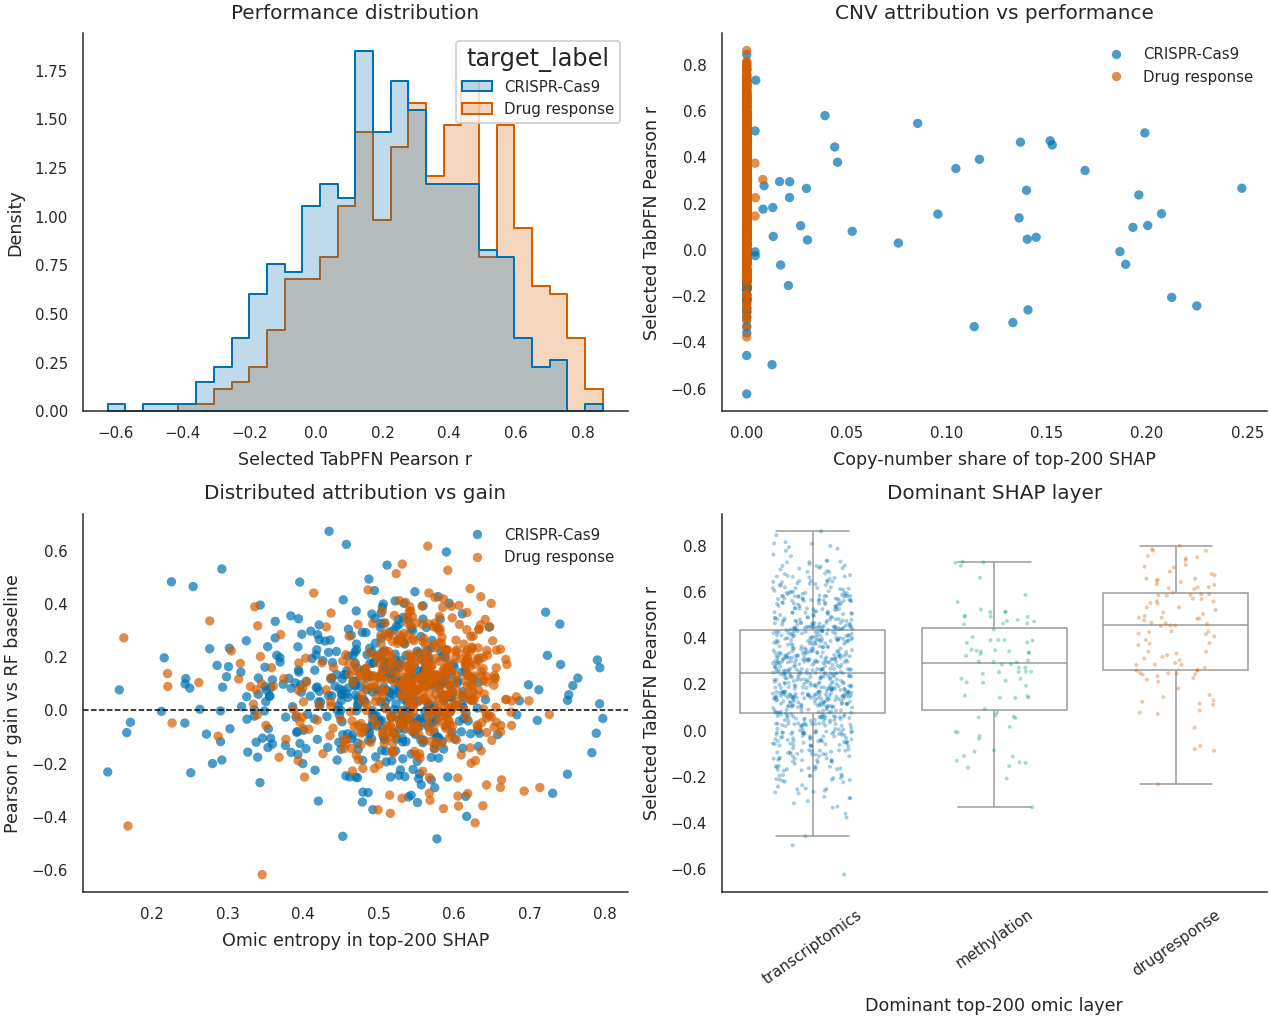

In [18]:
plot_df = analysis.copy()
fig, axes = plt.subplots(2, 2, figsize=(7.1, 5.7), constrained_layout=True)

sns.histplot(
    data=plot_df,
    x="test_pearsonr_tabpfn",
    hue="target_label",
    palette=TARGET_COLORS,
    bins=28,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0, 0],
)
axes[0, 0].set_xlabel("Selected TabPFN Pearson r")
axes[0, 0].set_ylabel("Density")
axes[0, 0].set_title("Performance distribution")

sns.scatterplot(
    data=plot_df,
    x="share_copynumber",
    y="test_pearsonr_tabpfn",
    hue="target_label",
    palette=TARGET_COLORS,
    s=14,
    linewidth=0,
    alpha=0.7,
    ax=axes[0, 1],
)
axes[0, 1].set_xlabel("Copy-number share of top-200 SHAP")
axes[0, 1].set_ylabel("Selected TabPFN Pearson r")
axes[0, 1].set_title("CNV attribution vs performance")
axes[0, 1].legend(title="", frameon=False)

sns.scatterplot(
    data=plot_df,
    x="omic_entropy_top200",
    y="delta_pearsonr_vs_rf_overlap_original",
    hue="target_label",
    palette=TARGET_COLORS,
    s=14,
    linewidth=0,
    alpha=0.7,
    ax=axes[1, 0],
)
axes[1, 0].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[1, 0].set_xlabel("Omic entropy in top-200 SHAP")
axes[1, 0].set_ylabel("Pearson r gain vs RF baseline")
axes[1, 0].set_title("Distributed attribution vs gain")
axes[1, 0].legend(title="", frameon=False)

order = [o for o in OMIC_ORDER if o in set(plot_df["dominant_omic_top200"])]
sns.boxplot(
    data=plot_df,
    x="dominant_omic_top200",
    y="test_pearsonr_tabpfn",
    order=order,
    color="white",
    linewidth=0.6,
    fliersize=0,
    ax=axes[1, 1],
)
sns.stripplot(
    data=plot_df,
    x="dominant_omic_top200",
    y="test_pearsonr_tabpfn",
    order=order,
    hue="dominant_omic_top200",
    palette=OMIC_COLORS,
    size=1.6,
    alpha=0.35,
    jitter=0.22,
    ax=axes[1, 1],
    legend=False,
)
axes[1, 1].set_xlabel("Dominant top-200 omic layer")
axes[1, 1].set_ylabel("Selected TabPFN Pearson r")
axes[1, 1].set_title("Dominant SHAP layer")
axes[1, 1].tick_params(axis="x", rotation=35)

save_figure(fig, "fig5_target_shap_performance_diagnostics")
plt.show()


## Requested CRISPR Targets for Detailed Panels

Only the requested CRISPR-Cas12 targets are used for the detailed SHAP bar plots. Targets not present in the SHAP export are reported in the availability table and skipped for plotting.

In [19]:

REQUESTED_TARGETS = {
    "crisprcas9": ["TP53", "MDM2", "MDM4"],
}

requested_status = []
selected_rows = []
SELECTED_TARGETS = {}

for family, requested in REQUESTED_TARGETS.items():
    fam = analysis[analysis["target_family"] == family].copy()
    available = set(fam["target_name"])
    selected = []
    for order, target in enumerate(requested):
        is_available = target in available
        requested_status.append({
            "target_family": family,
            "target_label": TARGET_META[family],
            "requested_target": target,
            "available_in_shap_output": is_available,
        })
        if is_available:
            selected.append(target)
            row = fam[fam["target_name"] == target].copy()
            row["selection_order"] = order
            selected_rows.append(row)
    SELECTED_TARGETS[family] = selected

requested_status = pd.DataFrame(requested_status)
requested_status.to_csv(FIG_DIR / "requested_crispr_targets_availability.csv", index=False)
selected_table = pd.concat(selected_rows, ignore_index=True) if selected_rows else pd.DataFrame()
selected_table.to_csv(FIG_DIR / "selected_targets_for_shap_panels.csv", index=False)

display(requested_status)
if selected_table.empty:
    raise ValueError("None of the requested CRISPR targets are present in the SHAP output.")

display(selected_table[[
    "target_label", "target_name", "test_pearsonr_tabpfn", "delta_pearsonr_vs_rf_overlap_original",
    "dominant_omic_top200", "share_copynumber", "omic_entropy_top200",
]])


,target_family,target_label,requested_target,available_in_shap_output
0,crisprcas9,CRISPR-Cas9,TP53,False
1,crisprcas9,CRISPR-Cas9,MDM2,True
2,crisprcas9,CRISPR-Cas9,MDM4,True


,target_label,target_name,test_pearsonr_tabpfn,delta_pearsonr_vs_rf_overlap_original,dominant_omic_top200,share_copynumber,omic_entropy_top200
0,CRISPR-Cas9,MDM2,0.844062,0.102732,transcriptomics,0.0,0.604598
1,CRISPR-Cas9,MDM4,0.632683,0.149414,transcriptomics,0.0,0.567609


## Figure 2: Top SHAP Features for Requested CRISPR Targets

The panel below is restricted to requested targets available in the SHAP run. Omic layer is encoded by color, while the y-axis shows only the feature name so labels remain readable.

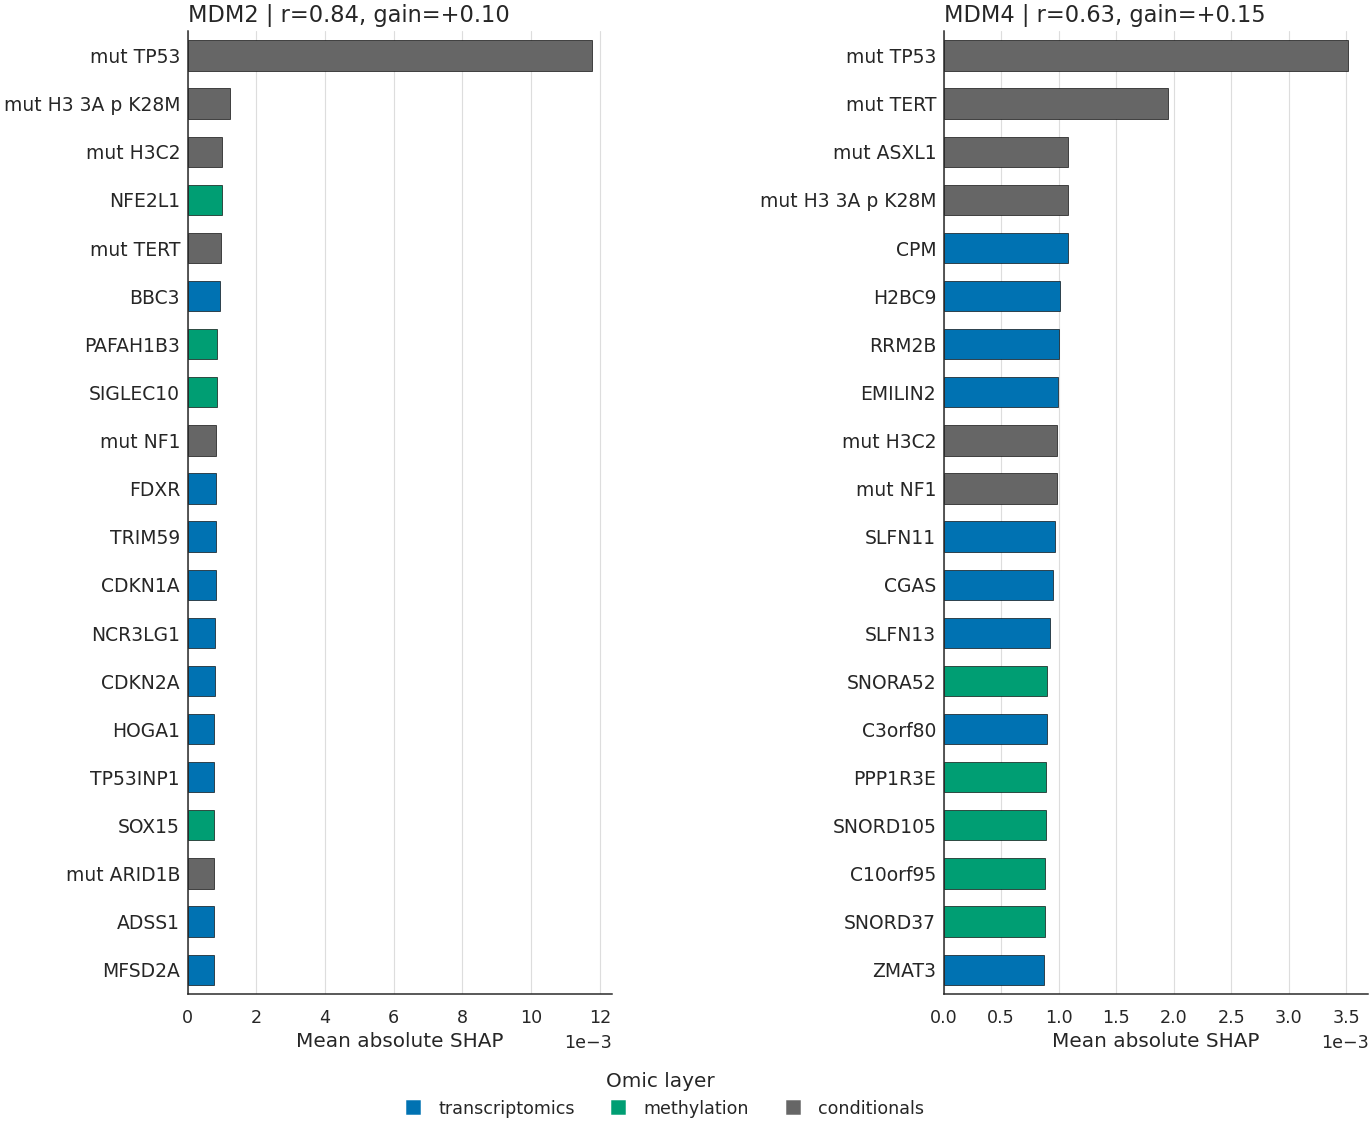

In [20]:

def target_title(target_name, row):
    return (
        f"{target_name} | r={row['test_pearsonr_tabpfn']:.2f}, "
        f"gain={row['delta_pearsonr_vs_rf_overlap_original']:+.2f}"
    )


def readable_feature_label(feature, width=32):
    feature = str(feature)
    body = feature.split("_", 1)[1] if "_" in feature else feature
    body = body.replace("__", " / ").replace("_", " ")
    return textwrap.shorten(body, width=width, placeholder="...")


def plot_requested_crispr_target_features(top_n=20):
    """
    Plot selected CRISPR targets' top features side-by-side (left-right),
    with each target in a column, instead of a row; plot top_n features per target.
    """
    family = "crisprcas9"
    targets = SELECTED_TARGETS.get(family, [])
    if not targets:
        raise ValueError("No requested CRISPR targets are available to plot.")

    n = len(targets)
    fig_width = max(n * 4.1, 7.8)
    fig_height = max(3.0, 0.25 * top_n + 1.6)
    fig, axes = plt.subplots(1, n, figsize=(fig_width, fig_height), constrained_layout=False)
    if n == 1:
        axes = [axes]

    perf_lookup = analysis[analysis["target_family"] == family].set_index("target_name")
    panel_rows = []
    legend_layers = set()

    for idx, (ax, target) in enumerate(zip(axes, targets)):
        d = top_features[family][top_features[family]["target_name"] == target].head(top_n).copy()
        d = d.sort_values("mean_abs_shap", ascending=True)
        panel_rows.append(d.assign(panel_target=target))
        legend_layers.update(d["omic_layer"])

        y = np.arange(len(d))
        colors = [OMIC_COLORS.get(layer, "#999999") for layer in d["omic_layer"]]
        ax.barh(y, d["mean_abs_shap"], color=colors, edgecolor="black", linewidth=0.25, height=0.63)
        ax.set_ylim(-0.5, len(d) - 0.5)
        ax.set_yticks(y)
        ax.set_yticklabels([readable_feature_label(v) for v in d["omics_feature"]], fontsize=7.5)
        ax.tick_params(axis="x", labelsize=7)
        ax.tick_params(axis="y", length=0, pad=3)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(-3, -3))
        ax.xaxis.get_offset_text().set_fontsize(7)
        ax.set_title(target_title(target, perf_lookup.loc[target]), loc="left", pad=4, fontsize=9)
        ax.grid(axis="x", color="#dddddd", linewidth=0.45)
        ax.set_xlabel("Mean absolute SHAP", fontsize=8, labelpad=2)

    legend_order = [layer for layer in OMIC_ORDER if layer in legend_layers]
    handles = [plt.Line2D([0], [0], marker="s", linestyle="", color=OMIC_COLORS[layer], label=layer) for layer in legend_order]
    if handles:
        fig.legend(
            handles=handles,
            title="Omic layer",
            frameon=False,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.01),
            borderaxespad=0.0,
            handletextpad=0.45,
            columnspacing=1.5,
            ncol=min(3, len(handles)),
            fontsize=7,
            title_fontsize=8,
        )
    fig.subplots_adjust(left=0.18, right=0.98, top=0.93, bottom=0.12, wspace=0.78)
    save_figure(fig, "fig6_requested_crispr_target_top_features")

    panel_df = pd.concat(panel_rows, ignore_index=True)
    panel_df.to_csv(FIG_DIR / "selected_target_top_features_crisprcas9.csv", index=False)
    return fig

fig = plot_requested_crispr_target_features(top_n=20)
plt.show()


## Figure 3: Omic Composition of Requested CRISPR Targets

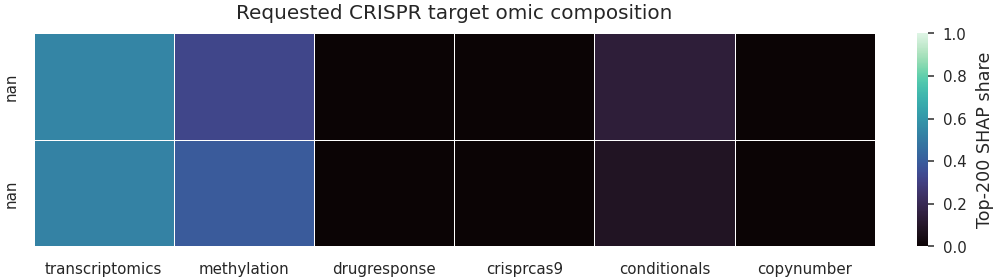

In [21]:

selected_profiles = analysis.merge(
    selected_table[["target_family", "target_name", "selection_order"]],
    on=["target_family", "target_name"],
    how="inner",
).sort_values(["target_family", "selection_order"])
share_cols = [f"share_{layer}" for layer in OMIC_ORDER if f"share_{layer}" in selected_profiles.columns]
heat = selected_profiles.set_index("target_label").copy()
heat["row_label"] = selected_profiles["target_label"] + " | " + selected_profiles["target_name"]
plot_mat = heat.set_index("row_label")[share_cols]
plot_mat.columns = [c.replace("share_", "") for c in plot_mat.columns]

fig, ax = plt.subplots(figsize=(5.6, max(1.6, 0.55 * len(plot_mat))), constrained_layout=True)
sns.heatmap(
    plot_mat,
    cmap="mako",
    vmin=0,
    vmax=1,
    linewidths=0.25,
    linecolor="white",
    cbar_kws={"label": "Top-200 SHAP share"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Requested CRISPR target omic composition")
save_figure(fig, "fig7_requested_crispr_target_omic_composition")
plt.show()


## Tables for Follow-Up Analysis


In [22]:
# Most CNV-attributed targets by family.
cnv_targets = analysis.sort_values(["target_family", "share_copynumber"], ascending=[True, False]).groupby("target_family").head(25)
cnv_targets.to_csv(FIG_DIR / "targets_high_copynumber_shap_share.csv", index=False)
display(cnv_targets[[
    "target_label", "target_name", "share_copynumber", "copynumber_feature_count_top200",
    "test_pearsonr_tabpfn", "delta_pearsonr_vs_rf_overlap_original", "dominant_omic_top200",
]])

# Top winners and losers against the RF overlap/original baseline.
gain_tables = []
for family in TARGET_META:
    fam = analysis[analysis["target_family"] == family]
    gain_tables.append(fam.nlargest(20, "delta_pearsonr_vs_rf_overlap_original").assign(direction="top_gain"))
    gain_tables.append(fam.nsmallest(20, "delta_pearsonr_vs_rf_overlap_original").assign(direction="top_loss"))
gain_tables = pd.concat(gain_tables, ignore_index=True)
gain_tables.to_csv(FIG_DIR / "targets_top_gain_loss_vs_rf_baseline.csv", index=False)
display(gain_tables[[
    "direction", "target_label", "target_name", "test_pearsonr_tabpfn", "test_pearsonr_rf_overlap_original",
    "delta_pearsonr_vs_rf_overlap_original", "dominant_omic_top200", "share_copynumber",
]].head(30))


,target_label,target_name,share_copynumber,copynumber_feature_count_top200,test_pearsonr_tabpfn,delta_pearsonr_vs_rf_overlap_original,dominant_omic_top200
14,CRISPR-Cas9,ANLN,0.247354,38,0.265618,0.188888,transcriptomics
12,CRISPR-Cas9,ANAPC5,0.224848,38,-0.243278,0.035558,transcriptomics
257,CRISPR-Cas9,PFDN6,0.212307,38,-0.206428,0.024336,transcriptomics
262,CRISPR-Cas9,PLRG1,0.207220,38,0.155346,0.206038,transcriptomics
308,CRISPR-Cas9,RACGAP1,0.200334,38,0.104431,-0.240043,transcriptomics
107,CRISPR-Cas9,EFTUD2,0.198889,38,0.504903,-0.080762,transcriptomics
168,CRISPR-Cas9,KCMF1,0.195894,38,0.236675,0.323865,transcriptomics
192,CRISPR-Cas9,MED14,0.192925,38,0.096358,-0.086054,transcriptomics
301,CRISPR-Cas9,PSMD11,0.189295,38,-0.063394,-0.030846,transcriptomics
224,CRISPR-Cas9,NCL,0.186445,38,-0.008340,0.120833,transcriptomics


,direction,target_label,target_name,test_pearsonr_tabpfn,test_pearsonr_rf_overlap_original,delta_pearsonr_vs_rf_overlap_original,dominant_omic_top200,share_copynumber
0,top_gain,CRISPR-Cas9,PSMA2,0.314911,-0.357518,0.672429,transcriptomics,0.000000
1,top_gain,CRISPR-Cas9,AURKB,0.319008,-0.304089,0.623096,transcriptomics,0.000000
2,top_gain,CRISPR-Cas9,BARD1,0.412425,-0.182286,0.594710,transcriptomics,0.000000
3,top_gain,CRISPR-Cas9,SMARCC1,0.710561,0.165370,0.545191,transcriptomics,0.000000
4,top_gain,CRISPR-Cas9,RANGAP1,0.437430,-0.093345,0.530775,transcriptomics,0.000000
5,top_gain,CRISPR-Cas9,POLR3B,0.505672,0.012839,0.492832,transcriptomics,0.000000
6,top_gain,CRISPR-Cas9,HAUS2,0.075926,-0.406589,0.482514,transcriptomics,0.000000
7,top_gain,CRISPR-Cas9,XPO5,0.456206,-0.025307,0.481513,transcriptomics,0.000000
8,top_gain,CRISPR-Cas9,RBM39,0.421824,-0.042943,0.464767,transcriptomics,0.000000
9,top_gain,CRISPR-Cas9,WDR12,0.643684,0.193867,0.449817,transcriptomics,0.000000


## Output Files


In [23]:
for path in sorted(FIG_DIR.glob("fig*")):
    print(path.relative_to(ROOT))
for path in sorted(FIG_DIR.glob("*target*csv")):
    print(path.relative_to(ROOT))


reports/cba2026/shap_analysis/20260505_131645/fig1_global_omic_ranking.pdf
reports/cba2026/shap_analysis/20260505_131645/fig1_global_omic_ranking.png
reports/cba2026/shap_analysis/20260505_131645/fig1_global_omic_ranking.svg
reports/cba2026/shap_analysis/20260505_131645/fig2_global_top_features.pdf
reports/cba2026/shap_analysis/20260505_131645/fig2_global_top_features.png
reports/cba2026/shap_analysis/20260505_131645/fig2_global_top_features.svg
reports/cba2026/shap_analysis/20260505_131645/fig3_global_feature_heatmap.pdf
reports/cba2026/shap_analysis/20260505_131645/fig3_global_feature_heatmap.png
reports/cba2026/shap_analysis/20260505_131645/fig3_global_feature_heatmap.svg
reports/cba2026/shap_analysis/20260505_131645/fig4_target_omic_composition_top200.pdf
reports/cba2026/shap_analysis/20260505_131645/fig4_target_omic_composition_top200.png
reports/cba2026/shap_analysis/20260505_131645/fig4_target_omic_composition_top200.svg
reports/cba2026/shap_analysis/20260505_131645/fig5_target_